<a href="https://colab.research.google.com/github/dennisgathu8/36CHAMBERS/blob/main/Enter_the_WU_36_CHAMBERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install spotipy

import requests
import base64
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from google.colab import files

# Spotify API credentials
CLIENT_ID = 'b95279648f384294a58551efb51c546f'
CLIENT_SECRET = '7e731490553d4a2784dccc3a110739d5'

# Base64 encode the client ID and client secret
client_credentials = f"{CLIENT_ID}:{CLIENT_SECRET}"
client_credentials_base64 = base64.b64encode(client_credentials.encode())

# Get the access token from Spotify API
token_url = 'https://accounts.spotify.com/api/token'
headers = {
    'Authorization': f'Basic {client_credentials_base64.decode()}'
}
data = {
    'grant_type': 'client_credentials'
}
response = requests.post(token_url, data=data, headers=headers)

if response.status_code == 200:
    access_token = response.json()['access_token']
    print("Access token obtained successfully.")
else:
    print("Error obtaining access token.")
    exit()

# get playlist data from Spotify
def get_trending_playlist_data(playlist_id, access_token):
    sp = spotipy.Spotify(auth=access_token)
    playlist_tracks = sp.playlist_tracks(playlist_id, fields='items(track(id, name, artists, album(id, name)))')

    music_data = []
    for track_info in playlist_tracks['items']:
        track = track_info['track']
        track_name = track['name']
        artists = ', '.join([artist['name'] for artist in track['artists']])
        album_name = track['album']['name']
        album_id = track['album']['id']
        track_id = track['id']

        # Get audio features for the track
        audio_features = sp.audio_features(track_id)[0] if track_id != 'Not available' else None

        # Get release date of the album
        try:
            album_info = sp.album(album_id) if album_id != 'Not available' else None
            release_date = album_info['release_date'] if album_info else None
        except:
            release_date = None

        # Get popularity of the track
        try:
            track_info = sp.track(track_id) if track_id != 'Not available' else None
            popularity = track_info['popularity'] if track_info else None
        except:
            popularity = None

        # Append track data to the list
        track_data = {
            'Track Name': track_name,
            'Artists': artists,
            'Album Name': album_name,
            'Album ID': album_id,
            'Track ID': track_id,
            'Popularity': popularity,
            'Release Date': release_date,
            'Duration (ms)': audio_features['duration_ms'] if audio_features else None,
            'Explicit': track_info.get('explicit', None),
            'External URLs': track_info.get('external_urls', {}).get('spotify', None),
            'Danceability': audio_features['danceability'] if audio_features else None,
            'Energy': audio_features['energy'] if audio_features else None,
            'Key': audio_features['key'] if audio_features else None,
            'Loudness': audio_features['loudness'] if audio_features else None,
            'Mode': audio_features['mode'] if audio_features else None,
            'Speechiness': audio_features['speechiness'] if audio_features else None,
            'Acousticness': audio_features['acousticness'] if audio_features else None,
            'Instrumentalness': audio_features['instrumentalness'] if audio_features else None,
            'Liveness': audio_features['liveness'] if audio_features else None,
            'Valence': audio_features['valence'] if audio_features else None,
            'Tempo': audio_features['tempo'] if audio_features else None,
        }

        music_data.append(track_data)

    # Create a DataFrame from the list of dictionaries
    df = pd.DataFrame(music_data)
    return df

# Spotify playlist ID
playlist_id = '7mpyCd3FQRgNx6LLAqhU3P'

# Get the playlist data and create a DataFrame
music_df = get_trending_playlist_data(playlist_id, access_token)

# Save the DataFrame as a CSV file
file_name = 'RazorMan_playlist_data.csv'
music_df.to_csv(file_name, index=False)

# Download the CSV file to the local system
files.download(file_name)

print(f"DataFrame saved and downloaded as {file_name}")


Access token obtained successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame saved and downloaded as RazorMan_playlist_data.csv


<ipython-input-3-e507d1f41655>:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


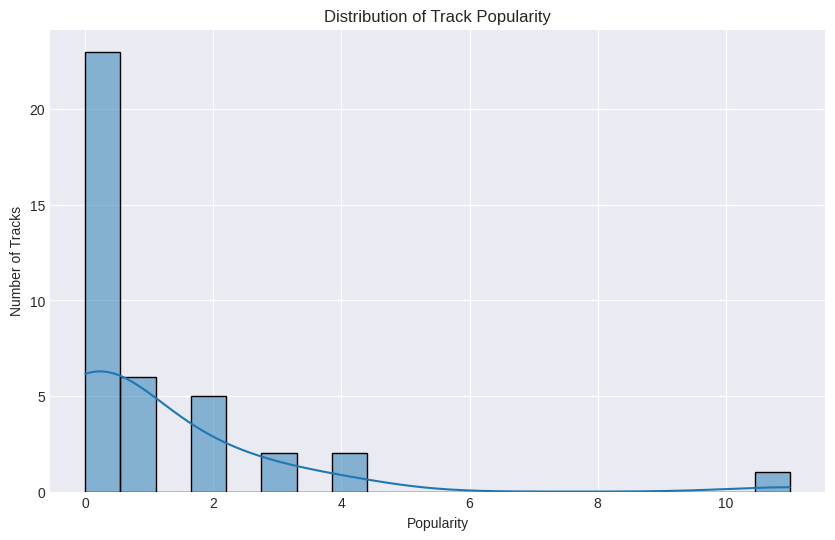

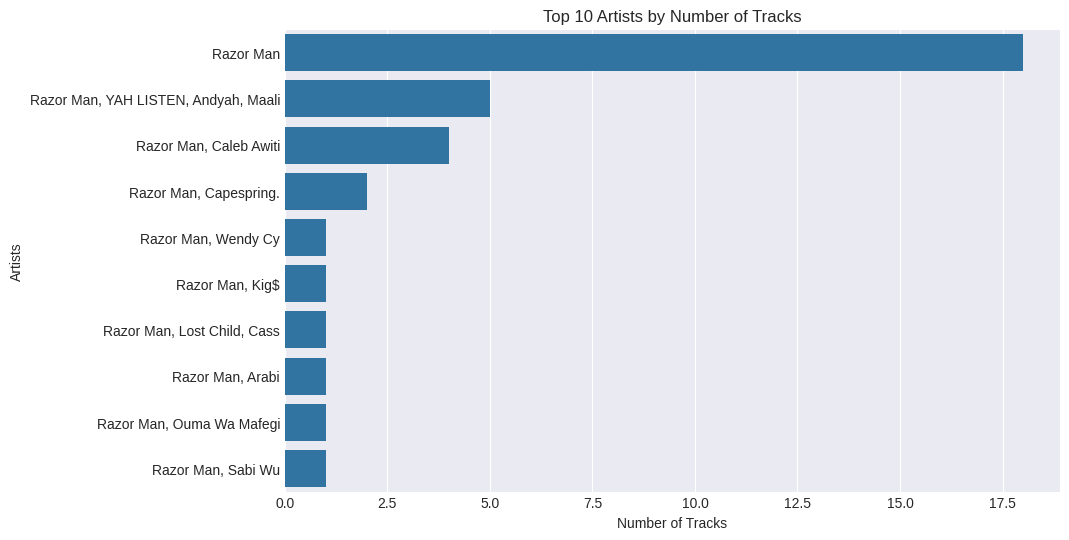

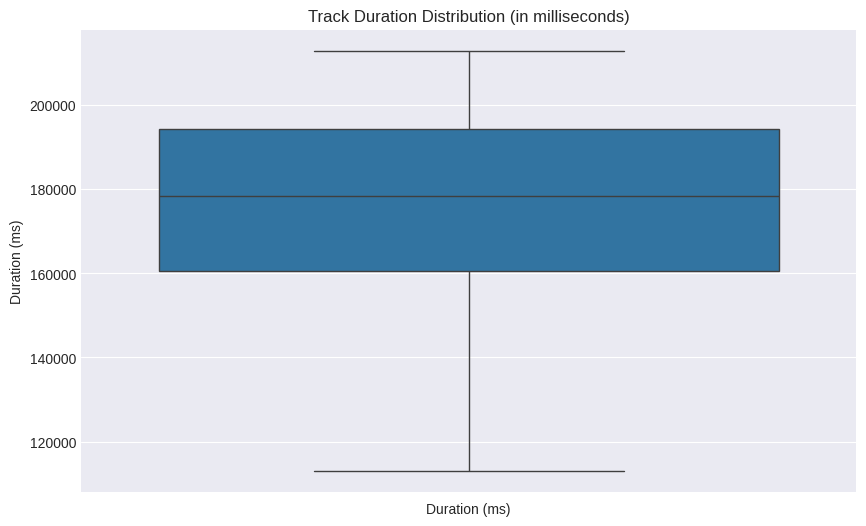

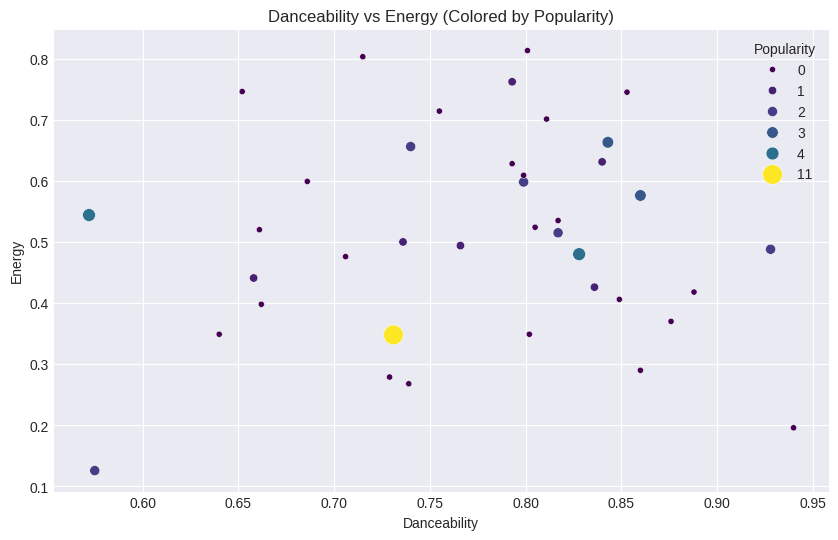

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting environment
plt.style.use('seaborn-darkgrid')

# 1. Popularity Distribution
plt.figure(figsize=(10, 6))
sns.histplot(music_df['Popularity'], kde=True, bins=20)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')
plt.show()

# 2. Top Artists (by number of tracks)
top_artists = music_df['Artists'].value_counts().head(10)  # Top 10 artists
plt.figure(figsize=(10, 6))
sns.barplot(y=top_artists.index, x=top_artists.values)
plt.title('Top 10 Artists by Number of Tracks')
plt.xlabel('Number of Tracks')
plt.ylabel('Artists')
plt.show()

# 3. Track Duration Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(music_df['Duration (ms)'])
plt.title('Track Duration Distribution (in milliseconds)')
plt.xlabel('Duration (ms)')
plt.show()

# 4. Danceability vs Energy
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Danceability', y='Energy', data=music_df, hue='Popularity', size='Popularity', sizes=(20, 200), palette='viridis')
plt.title('Danceability vs Energy (Colored by Popularity)')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()


<ipython-input-4-05ed614a2dc0>:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')
<ipython-input-4-05ed614a2dc0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')


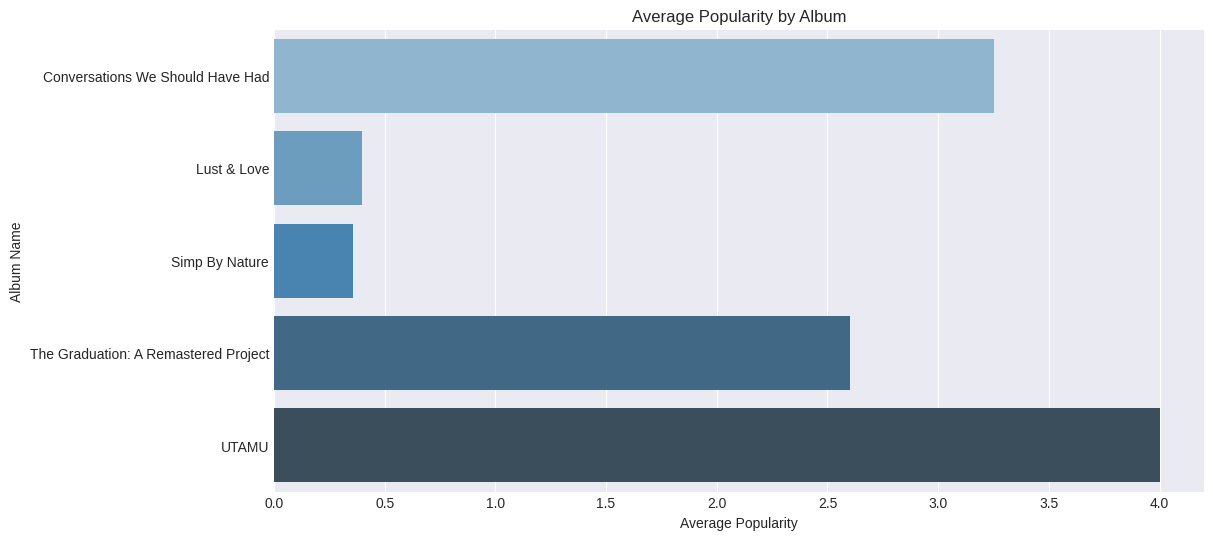

<ipython-input-4-05ed614a2dc0>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')


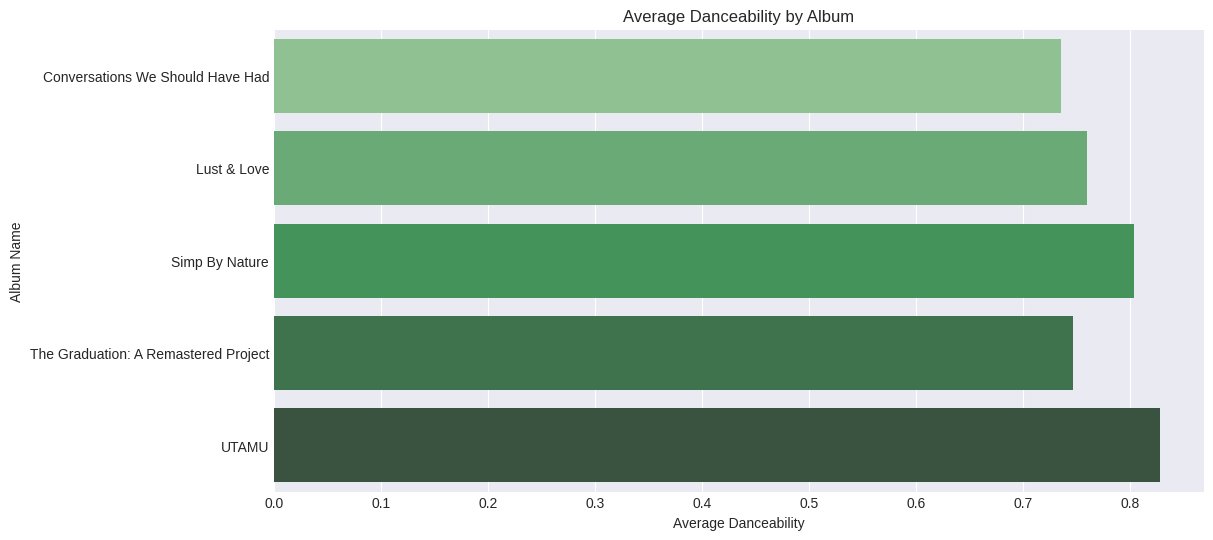

<ipython-input-4-05ed614a2dc0>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')


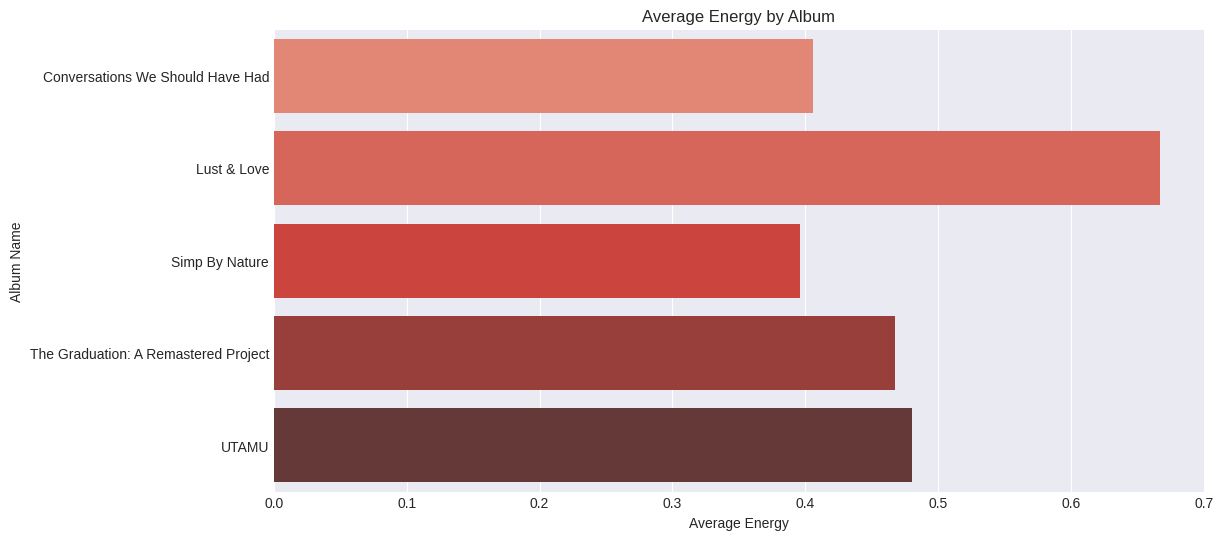

<ipython-input-4-05ed614a2dc0>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')


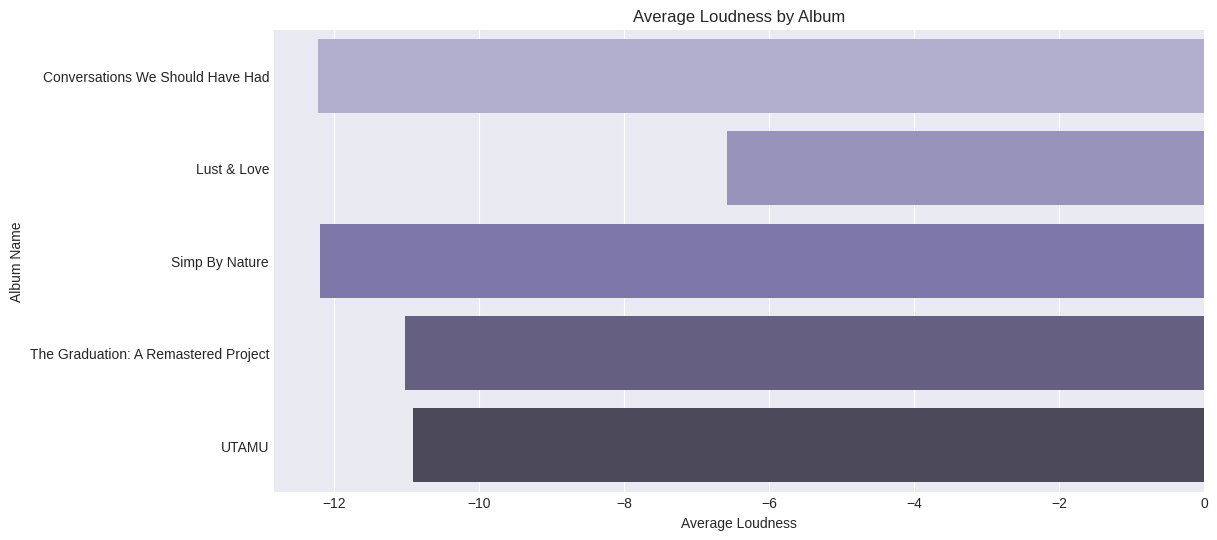

In [ ]:
# Select only numeric columns for aggregation
numeric_columns = ['Popularity', 'Danceability', 'Energy', 'Loudness', 'Tempo', 'Valence', 'Speechiness',
                   'Acousticness', 'Instrumentalness', 'Liveness', 'Duration (ms)']

# Group by 'Album Name' and compute the mean for numeric columns
album_performance = music_df.groupby('Album Name')[numeric_columns].mean().reset_index()

# Plotting setup
plt.style.use('seaborn-darkgrid')

# 1. Popularity by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Average Popularity by Album')
plt.xlabel('Average Popularity')
plt.ylabel('Album Name')
plt.show()

# 2. Danceability by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')
plt.title('Average Danceability by Album')
plt.xlabel('Average Danceability')
plt.ylabel('Album Name')
plt.show()

# 3. Energy by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')
plt.title('Average Energy by Album')
plt.xlabel('Average Energy')
plt.ylabel('Album Name')
plt.show()

# 4. Loudness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')
plt.title('Average Loudness by Album')
plt.xlabel('Average Loudness')
plt.ylabel('Album Name')
plt.show()


<ipython-input-5-c0db2f55228c>:17: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')
<ipython-input-5-c0db2f55228c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')


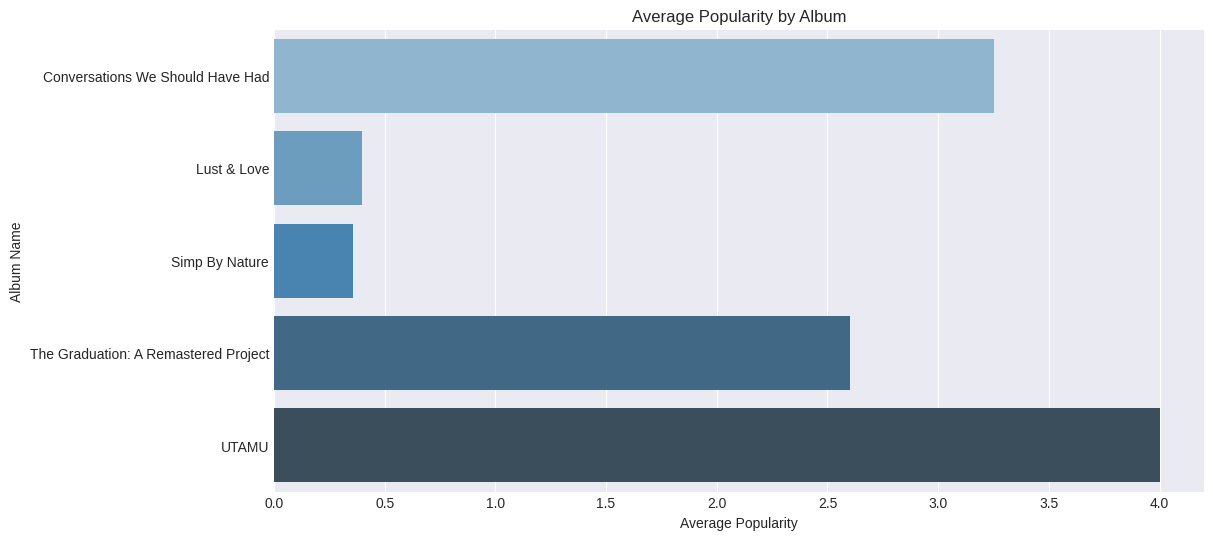

<ipython-input-5-c0db2f55228c>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')


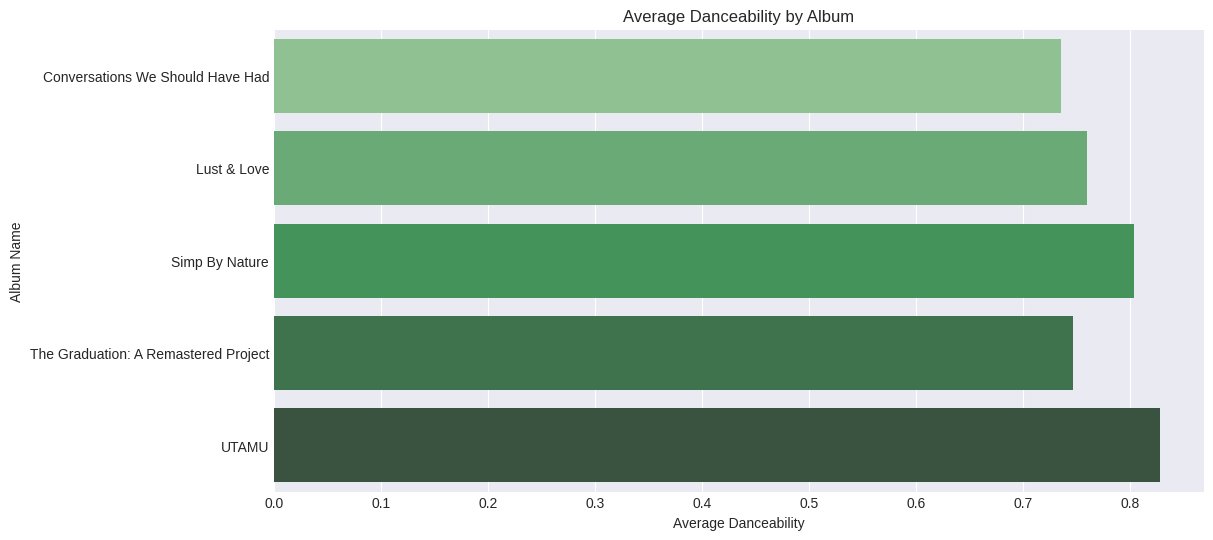

<ipython-input-5-c0db2f55228c>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')


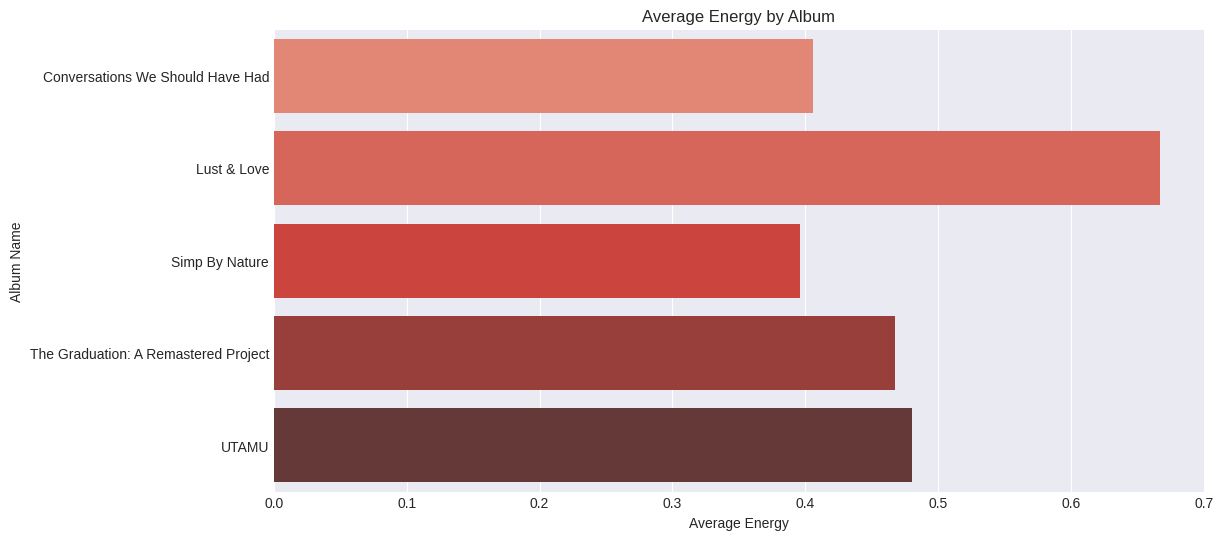

<ipython-input-5-c0db2f55228c>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')


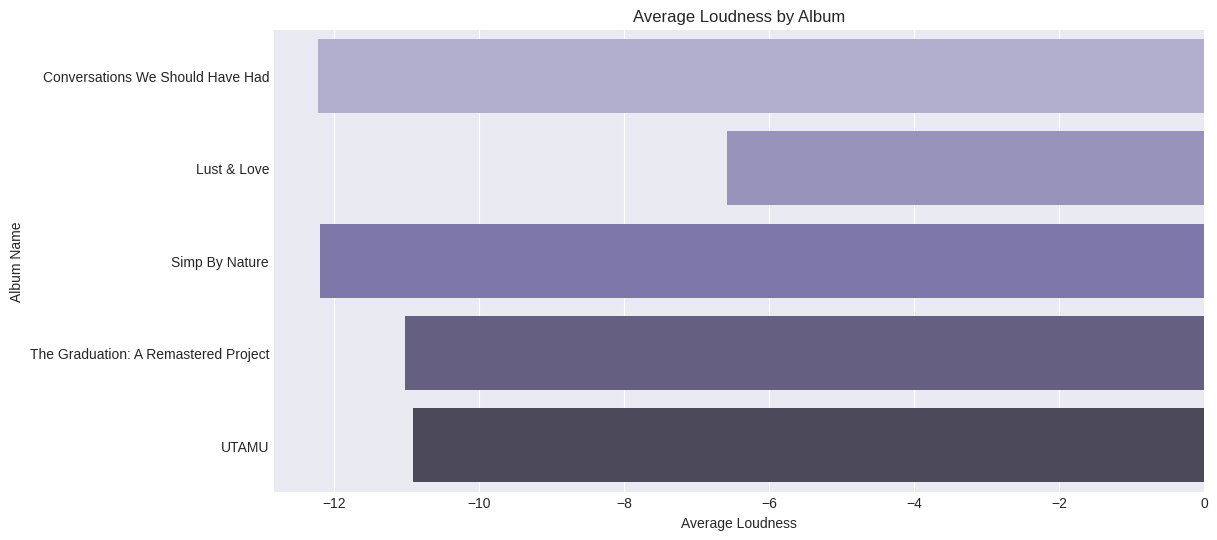

<ipython-input-5-c0db2f55228c>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Track Count', y='Album Name', data=album_performance, palette='Oranges_d')


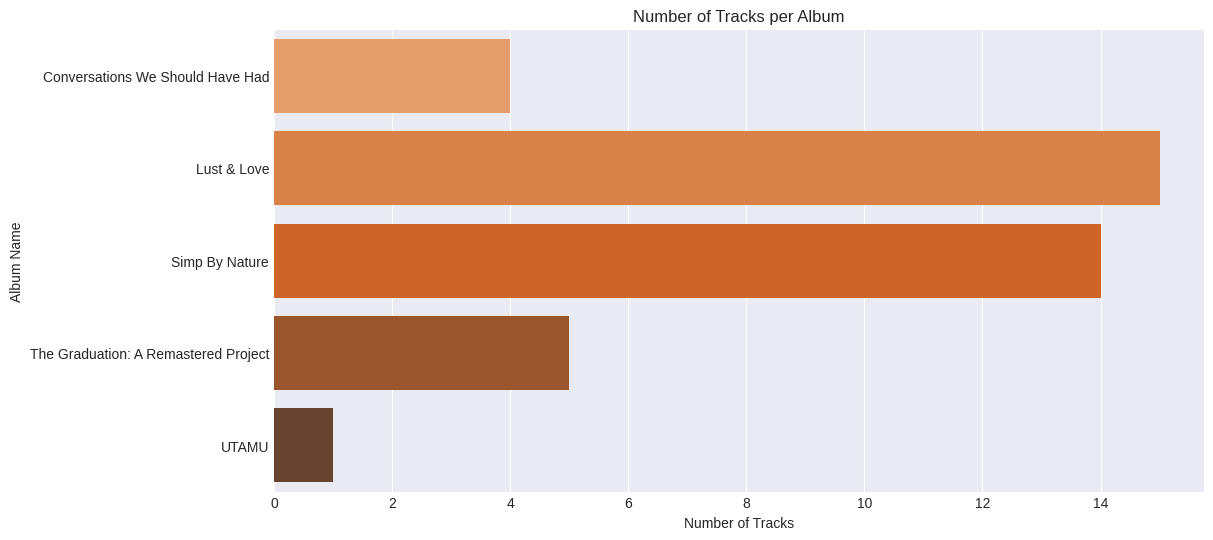

<ipython-input-5-c0db2f55228c>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Unique Artists', y='Album Name', data=album_performance, palette='Blues_d')


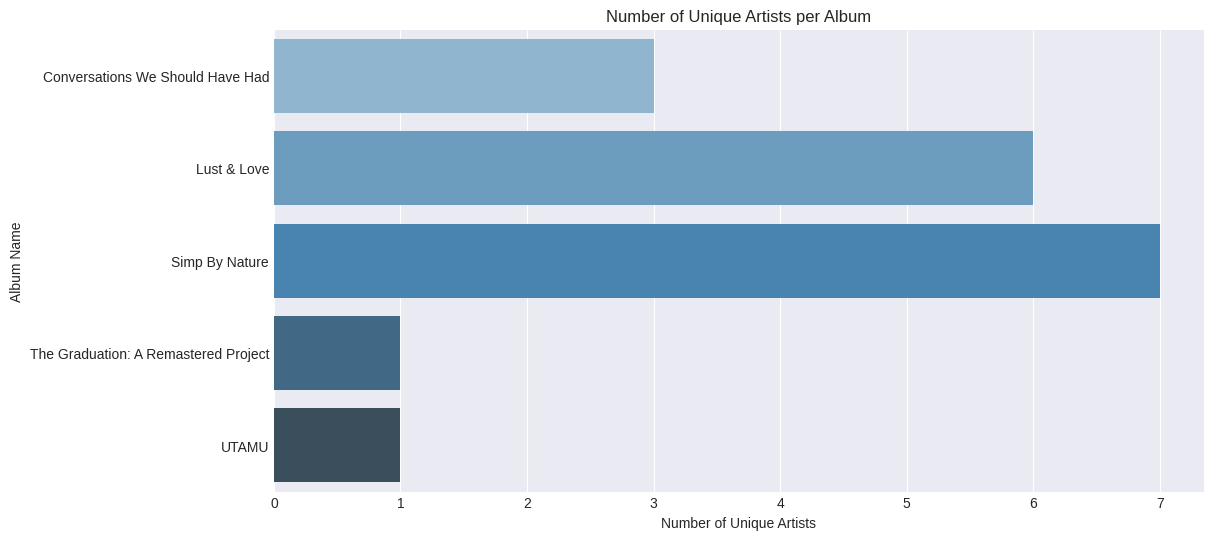

<ipython-input-5-c0db2f55228c>:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valence', y='Album Name', data=album_performance, palette='pink')


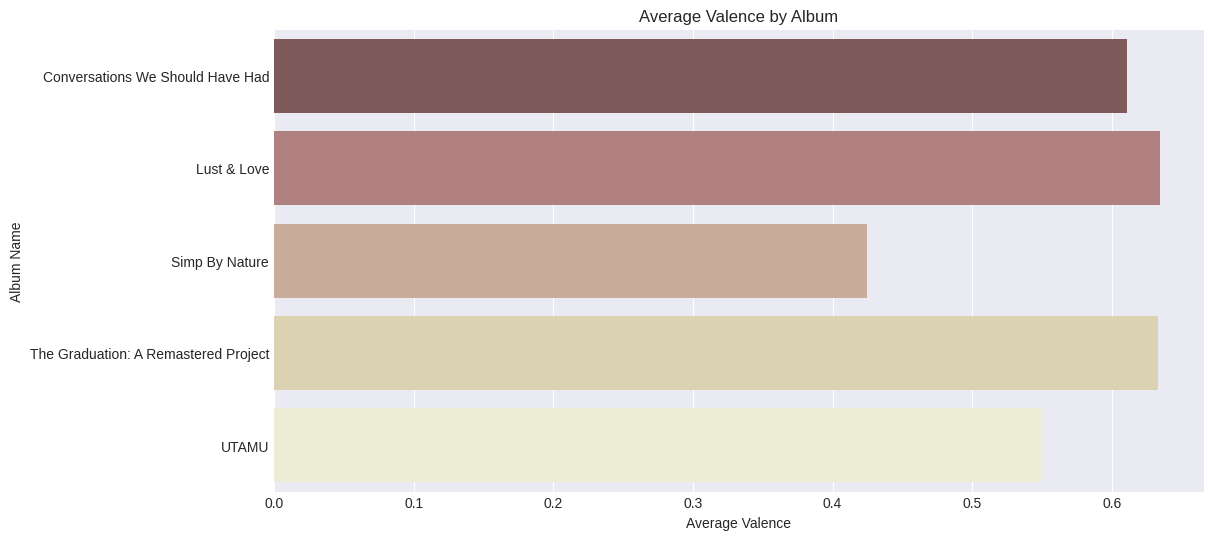

<ipython-input-5-c0db2f55228c>:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tempo', y='Album Name', data=album_performance, palette='Greens_d')


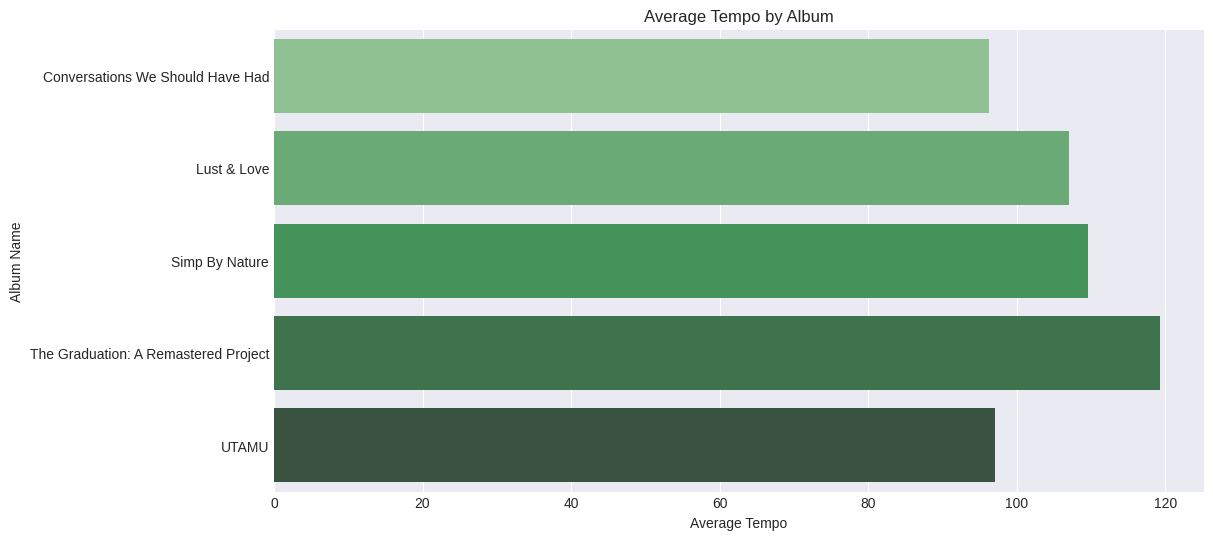

<ipython-input-5-c0db2f55228c>:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Acousticness', y='Album Name', data=album_performance, palette='Blues_d')


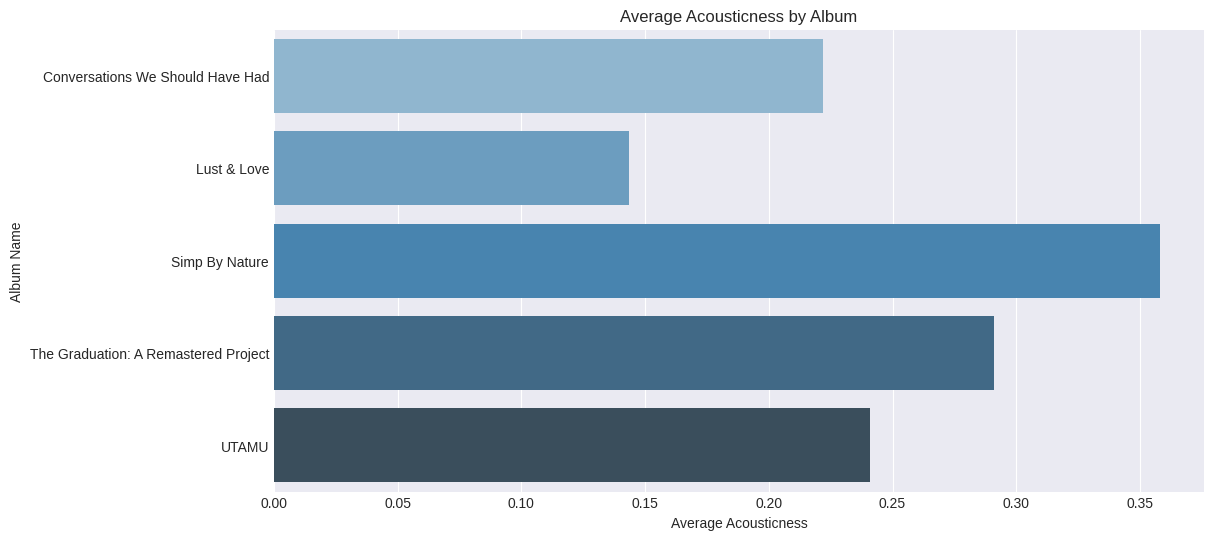

<ipython-input-5-c0db2f55228c>:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Instrumentalness', y='Album Name', data=album_performance, palette='Reds_d')


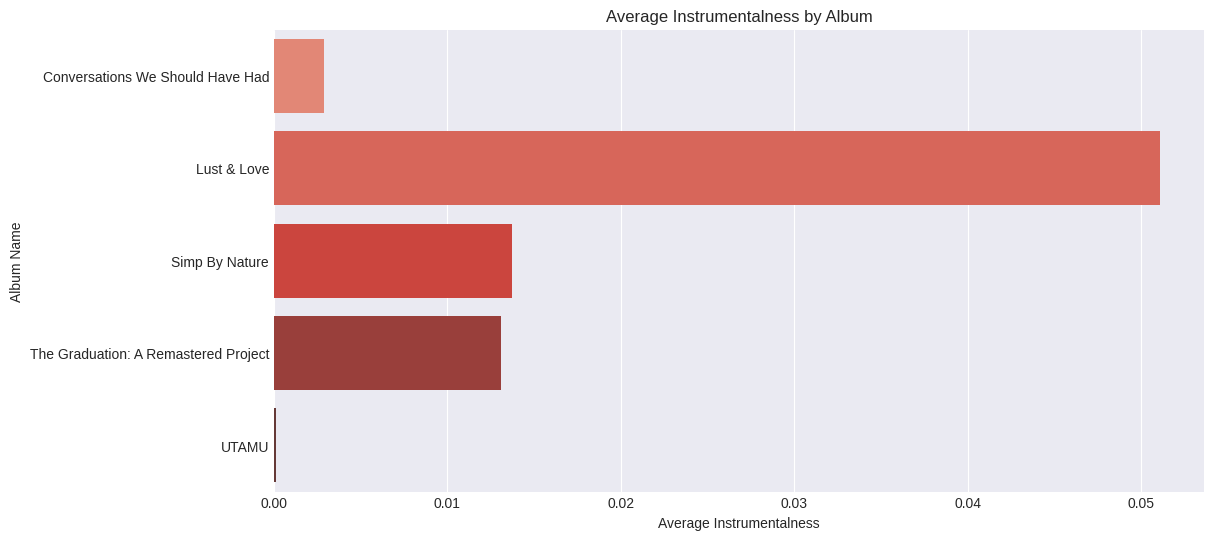

<ipython-input-5-c0db2f55228c>:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Liveness', y='Album Name', data=album_performance, palette='Purples_d')


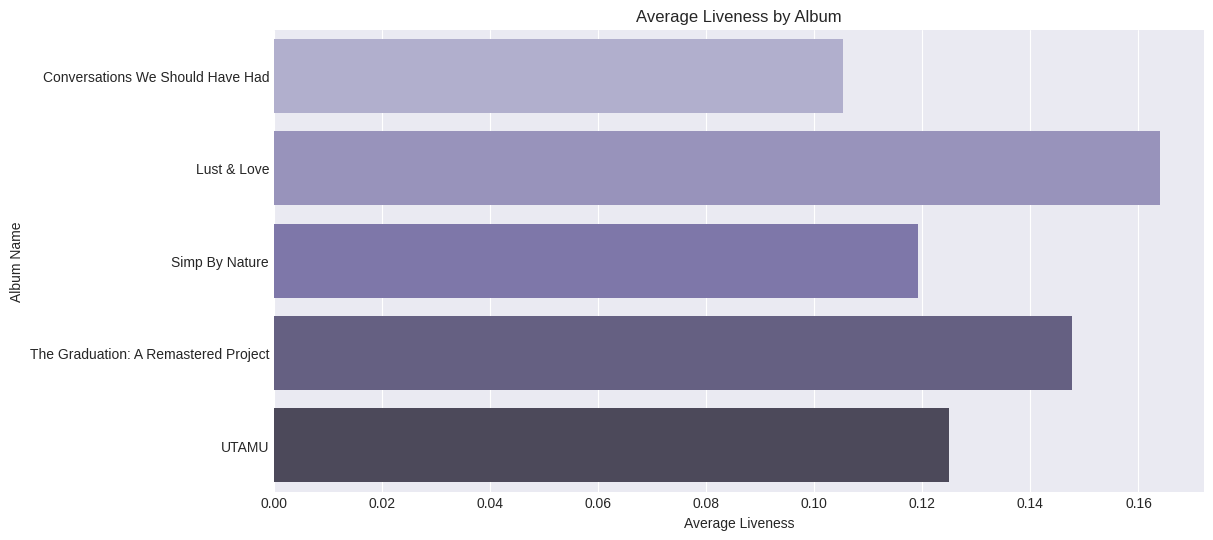

<ipython-input-5-c0db2f55228c>:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Speechiness', y='Album Name', data=album_performance, palette='Oranges_d')


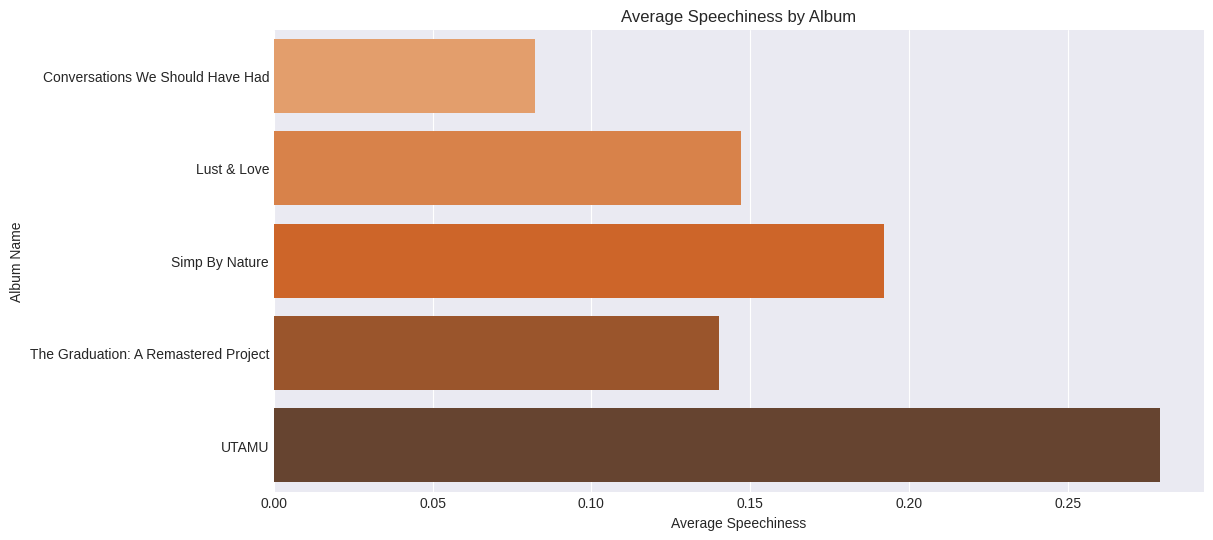

In [ ]:
# Numeric columns to be aggregated using mean
numeric_columns = ['Popularity', 'Danceability', 'Energy', 'Loudness', 'Tempo', 'Valence', 'Speechiness',
                   'Acousticness', 'Instrumentalness', 'Liveness', 'Duration (ms)']

# Group by 'Album Name' and compute the mean for numeric columns
album_performance = music_df.groupby('Album Name')[numeric_columns].mean().reset_index()

# Non-numeric columns: Count number of unique tracks and artists per album
album_track_count = music_df.groupby('Album Name')['Track Name'].count().reset_index(name='Track Count')
album_artist_count = music_df.groupby('Album Name')['Artists'].nunique().reset_index(name='Unique Artists')

# Merge track count and artist count with the numeric performance DataFrame
album_performance = pd.merge(album_performance, album_track_count, on='Album Name')
album_performance = pd.merge(album_performance, album_artist_count, on='Album Name')

# Plotting setup
plt.style.use('seaborn-darkgrid')

# 1. Popularity by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Popularity', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Average Popularity by Album')
plt.xlabel('Average Popularity')
plt.ylabel('Album Name')
plt.show()

# 2. Danceability by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Danceability', y='Album Name', data=album_performance, palette='Greens_d')
plt.title('Average Danceability by Album')
plt.xlabel('Average Danceability')
plt.ylabel('Album Name')
plt.show()

# 3. Energy by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Energy', y='Album Name', data=album_performance, palette='Reds_d')
plt.title('Average Energy by Album')
plt.xlabel('Average Energy')
plt.ylabel('Album Name')
plt.show()

# 4. Loudness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Loudness', y='Album Name', data=album_performance, palette='Purples_d')
plt.title('Average Loudness by Album')
plt.xlabel('Average Loudness')
plt.ylabel('Album Name')
plt.show()

# 5. Number of Tracks per Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Track Count', y='Album Name', data=album_performance, palette='Oranges_d')
plt.title('Number of Tracks per Album')
plt.xlabel('Number of Tracks')
plt.ylabel('Album Name')
plt.show()

# 6. Number of Unique Artists per Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Unique Artists', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Number of Unique Artists per Album')
plt.xlabel('Number of Unique Artists')
plt.ylabel('Album Name')
plt.show()

# 7. Valence by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Valence', y='Album Name', data=album_performance, palette='pink')
plt.title('Average Valence by Album')
plt.xlabel('Average Valence')
plt.ylabel('Album Name')
plt.show()

# 8. Tempo by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Tempo', y='Album Name', data=album_performance, palette='Greens_d')
plt.title('Average Tempo by Album')
plt.xlabel('Average Tempo')
plt.ylabel('Album Name')
plt.show()

# 9. Acousticness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Acousticness', y='Album Name', data=album_performance, palette='Blues_d')
plt.title('Average Acousticness by Album')
plt.xlabel('Average Acousticness')
plt.ylabel('Album Name')
plt.show()

# 10. Instrumentalness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Instrumentalness', y='Album Name', data=album_performance, palette='Reds_d')
plt.title('Average Instrumentalness by Album')
plt.xlabel('Average Instrumentalness')
plt.ylabel('Album Name')
plt.show()

# 11. Liveness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Liveness', y='Album Name', data=album_performance, palette='Purples_d')
plt.title('Average Liveness by Album')
plt.xlabel('Average Liveness')
plt.ylabel('Album Name')
plt.show()

# 12. Speechiness by Album
plt.figure(figsize=(12, 6))
sns.barplot(x='Speechiness', y='Album Name', data=album_performance, palette='Oranges_d')
plt.title('Average Speechiness by Album')
plt.xlabel('Average Speechiness')
plt.ylabel('Album Name')
plt.show()


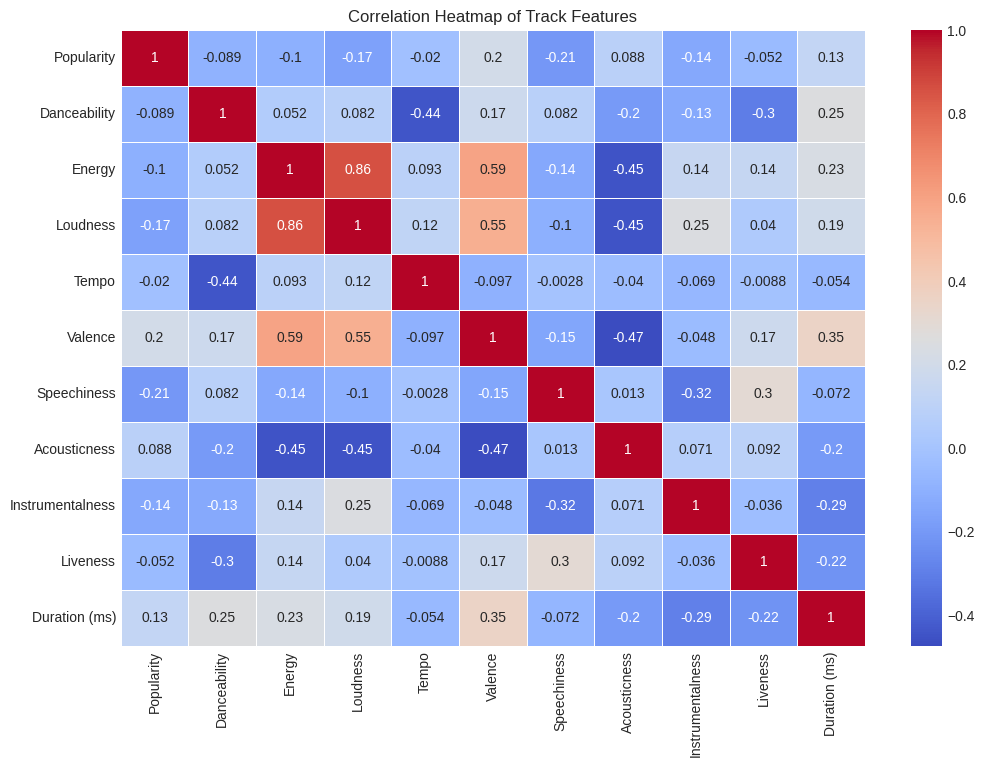

<ipython-input-6-2a35b1f36311>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Artists', data=top_artists_popularity, palette='Blues_d')


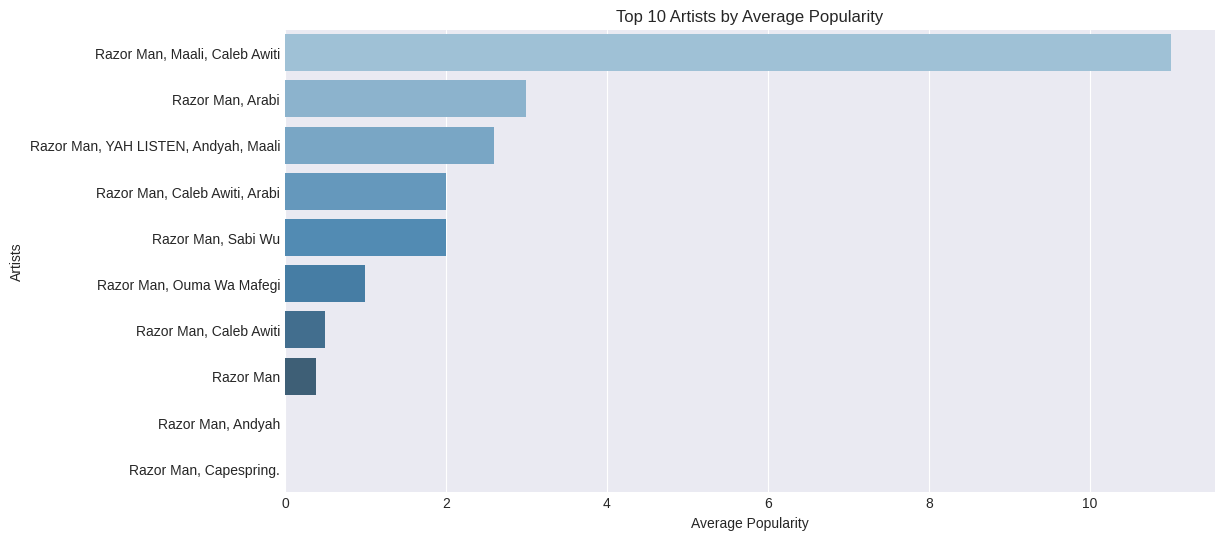

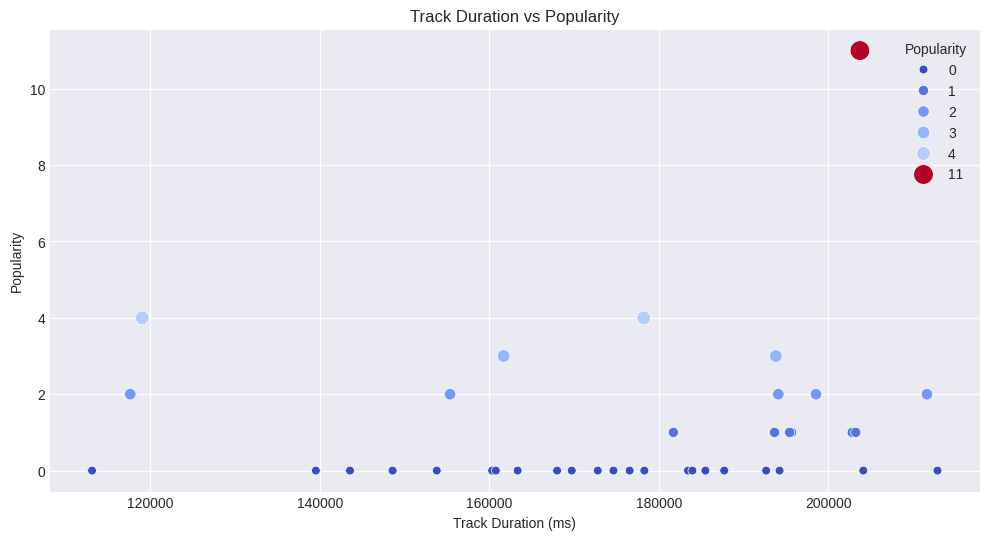

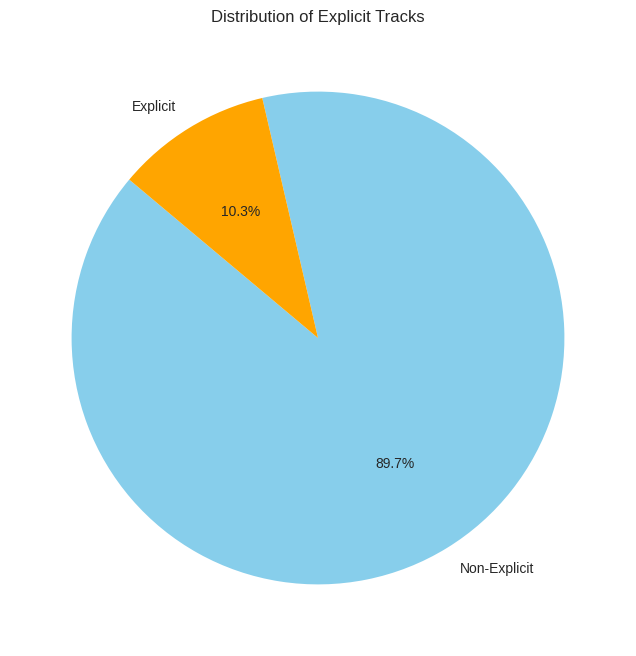

Genre information is not available in the dataset.


In [ ]:
import numpy as np

# 1. Correlation Heatmap of Numeric Features
plt.figure(figsize=(12, 8))
correlation_matrix = music_df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Track Features')
plt.show()

# 2. Top Artists by Average Popularity
# Group by Artists and calculate the mean popularity
top_artists_popularity = music_df.groupby('Artists')['Popularity'].mean().reset_index().sort_values(by='Popularity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Popularity', y='Artists', data=top_artists_popularity, palette='Blues_d')
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artists')
plt.show()

# 3. Track Duration vs. Popularity
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Duration (ms)', y='Popularity', data=music_df, hue='Popularity', palette='coolwarm', size='Popularity', sizes=(40, 200))
plt.title('Track Duration vs Popularity')
plt.xlabel('Track Duration (ms)')
plt.ylabel('Popularity')
plt.show()

# 4. Distribution of Explicit Tracks
# Create a count for explicit and non-explicit tracks
explicit_count = music_df['Explicit'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(explicit_count, labels=['Non-Explicit', 'Explicit'], autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange'])
plt.title('Distribution of Explicit Tracks')
plt.show()

# 5. Popularity of Genres (if Genre data is available)
# Let's assume the genre data is added as a 'Genre' column in the dataset

if 'Genre' in music_df.columns:
    top_genres_popularity = music_df.groupby('Genre')['Popularity'].mean().reset_index().sort_values(by='Popularity', ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Popularity', y='Genre', data=top_genres_popularity, palette='Purples_d')
    plt.title('Top 10 Genres by Average Popularity')
    plt.xlabel('Average Popularity')
    plt.ylabel('Genres')
    plt.show()
else:
    print("Genre information is not available in the dataset.")


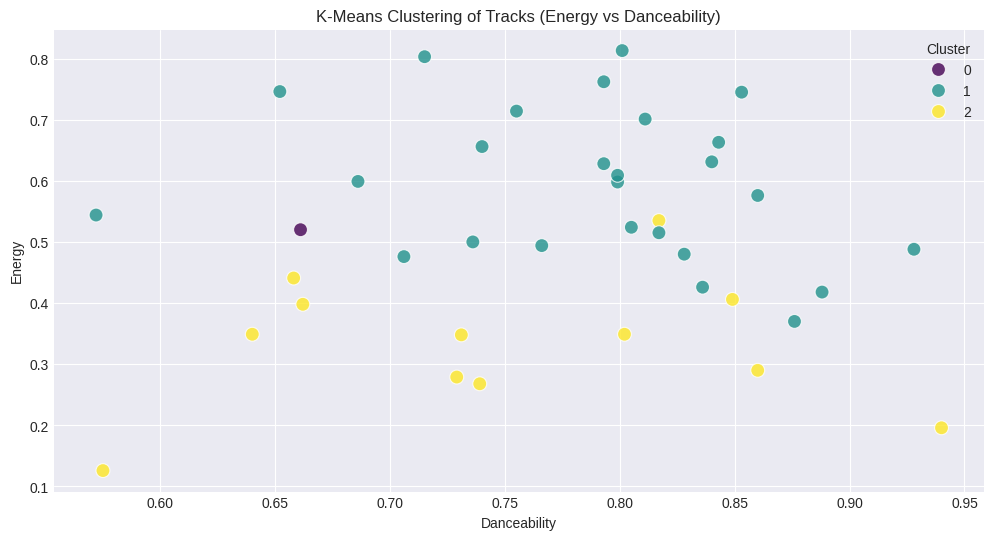

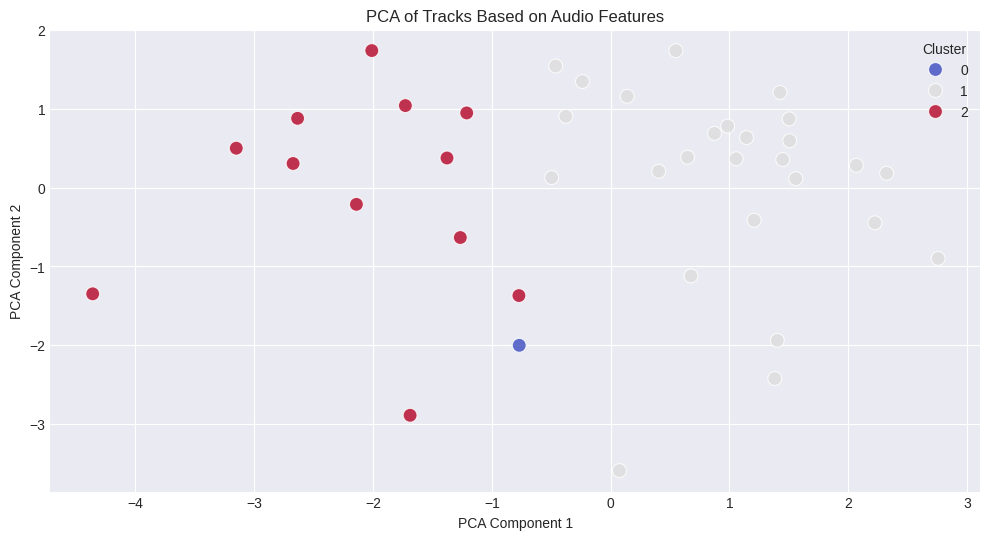

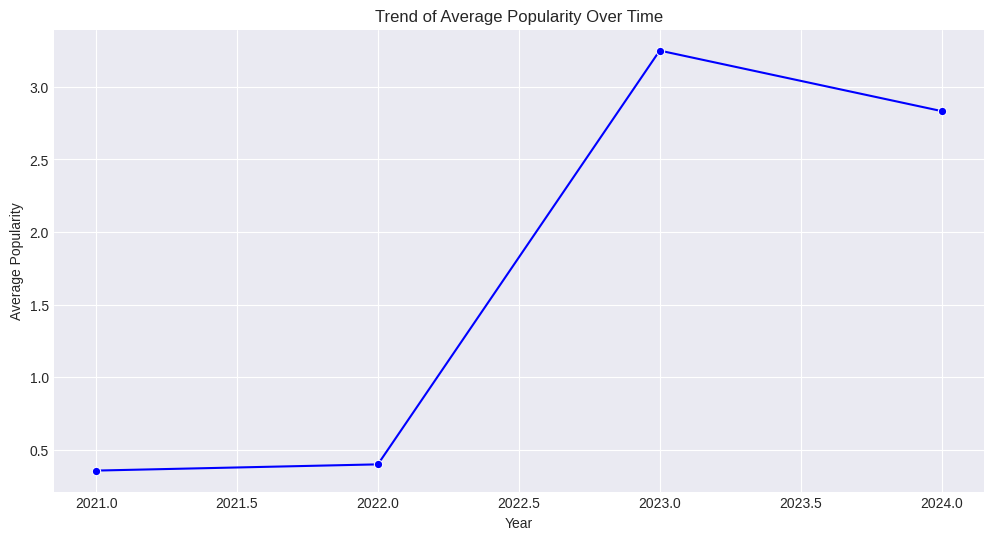

<ipython-input-7-86e177a0f5a5>:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=cluster_columns, palette='coolwarm')


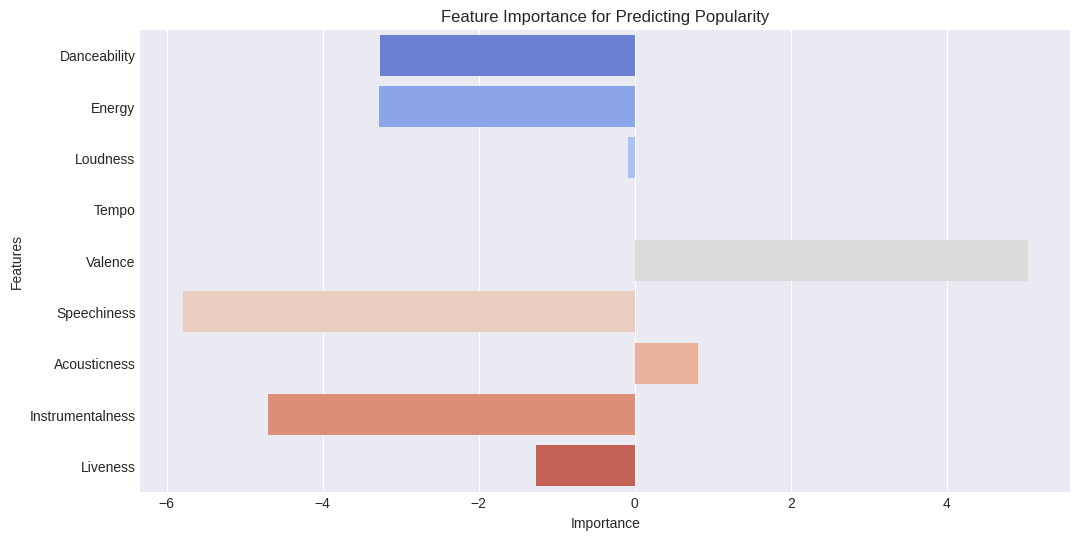

Model R^2 score: -0.22


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. K-Means Clustering based on Audio Features
# We'll use the numeric columns related to audio features for clustering
cluster_columns = ['Danceability', 'Energy', 'Loudness', 'Tempo', 'Valence', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness']
scaled_features = StandardScaler().fit_transform(music_df[cluster_columns])

# Perform K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
music_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize Clusters with a scatter plot of Energy vs Danceability
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Danceability', y='Energy', hue='Cluster', data=music_df, palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clustering of Tracks (Energy vs Danceability)')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()

# 2. Principal Component Analysis (PCA) for Dimensionality Reduction
# We will reduce the numeric features to 2D using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Add PCA components to the DataFrame for visualization
music_df['PCA1'] = pca_result[:, 0]
music_df['PCA2'] = pca_result[:, 1]

# Scatter plot of the PCA results
plt.figure(figsize=(12, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=music_df, palette='coolwarm', s=100, alpha=0.8)
plt.title('PCA of Tracks Based on Audio Features')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# 3. Trend Analysis Over Time (if Release Date is available)
if 'Release Date' in music_df.columns:
    # Convert 'Release Date' to datetime format if not already done
    music_df['Release Date'] = pd.to_datetime(music_df['Release Date'])

    # Group by year and calculate average popularity over time
    music_df['Year'] = music_df['Release Date'].dt.year
    popularity_over_time = music_df.groupby('Year')['Popularity'].mean().reset_index()

    # Plot the trend of popularity over time
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Year', y='Popularity', data=popularity_over_time, marker='o', color='blue')
    plt.title('Trend of Average Popularity Over Time')
    plt.xlabel('Year')
    plt.ylabel('Average Popularity')
    plt.show()
else:
    print("Release Date information is not available in the dataset.")

# 4. Feature Importance for Popularity (Regression Analysis)
# We'll use a linear regression model to assess feature importance for popularity
X = music_df[cluster_columns]  # Audio features as input
y = music_df['Popularity']  # Popularity as the target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and fit the linear regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Check feature importance (coefficients)
importance = reg.coef_

# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=importance, y=cluster_columns, palette='coolwarm')
plt.title('Feature Importance for Predicting Popularity')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

# Display the model's performance on the test set
print(f"Model R^2 score: {reg.score(X_test, y_test):.2f}")


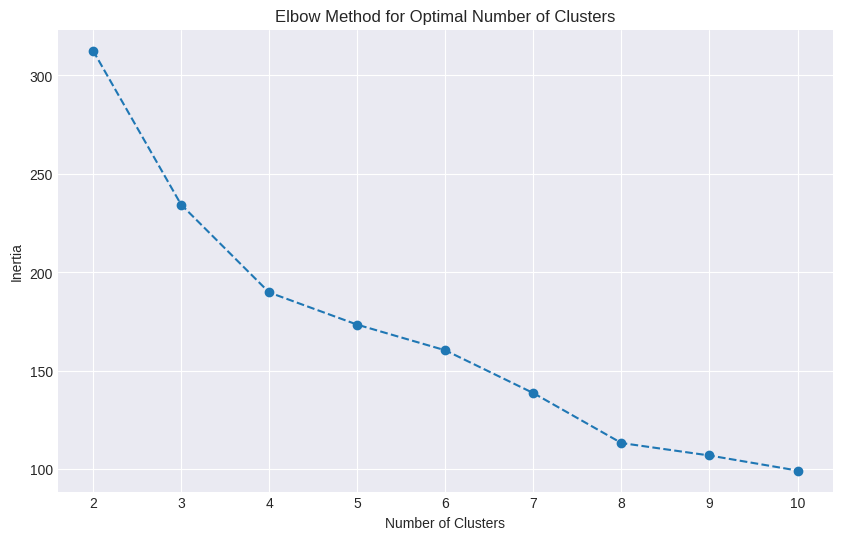

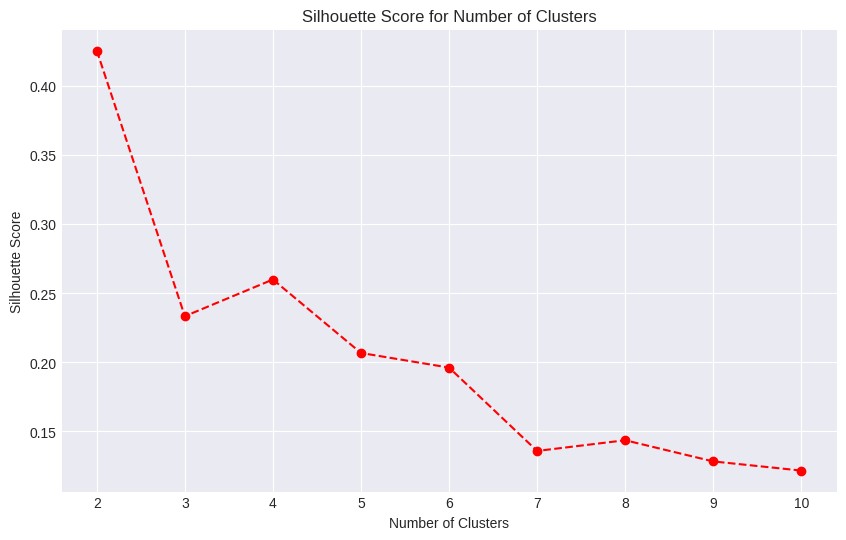

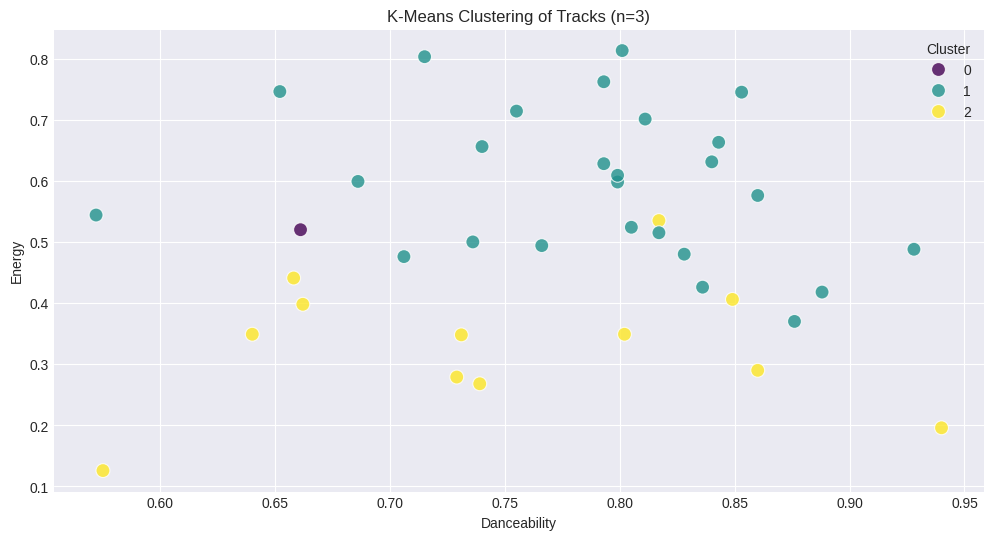

In [ ]:
from sklearn.metrics import silhouette_score

# Elbow method to find the optimal number of clusters
inertia = []
silhouette = []

for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(scaled_features, kmeans.labels_))

# Plot the inertia to see the "elbow"
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Plot silhouette scores to assess cluster quality
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette, marker='o', linestyle='--', color='red')
plt.title('Silhouette Score for Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Choose the optimal number of clusters based on the elbow or silhouette score (e.g., n=3)
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
music_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize clusters again
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Danceability', y='Energy', hue='Cluster', data=music_df, palette='viridis', s=100, alpha=0.8)
plt.title(f'K-Means Clustering of Tracks (n={optimal_clusters})')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()


<ipython-input-9-a8d7fcb0b3ff>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance, y=cluster_columns, palette='coolwarm')


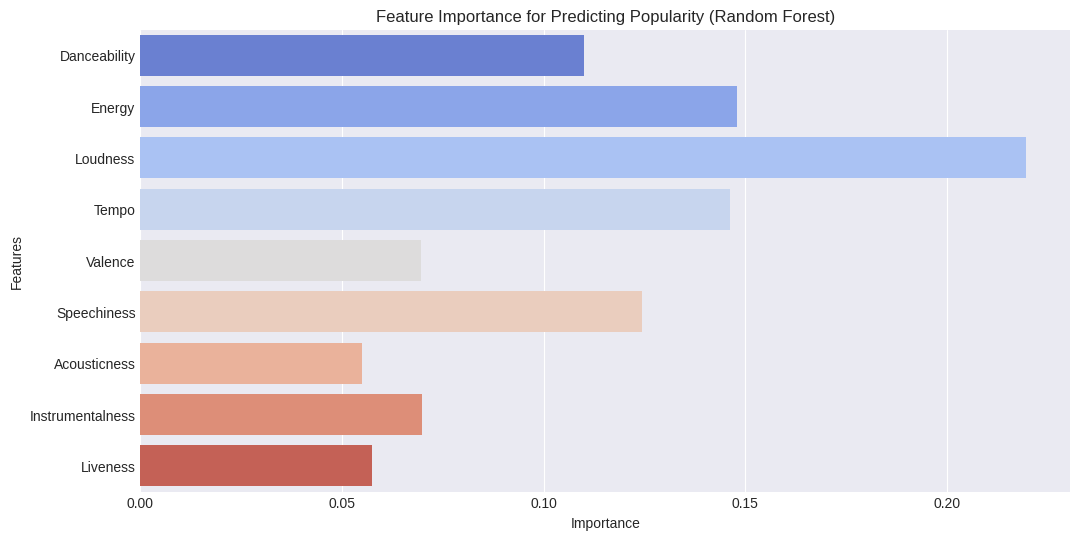

<ipython-input-9-a8d7fcb0b3ff>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ridge_importance, y=cluster_columns, palette='Purples_d')


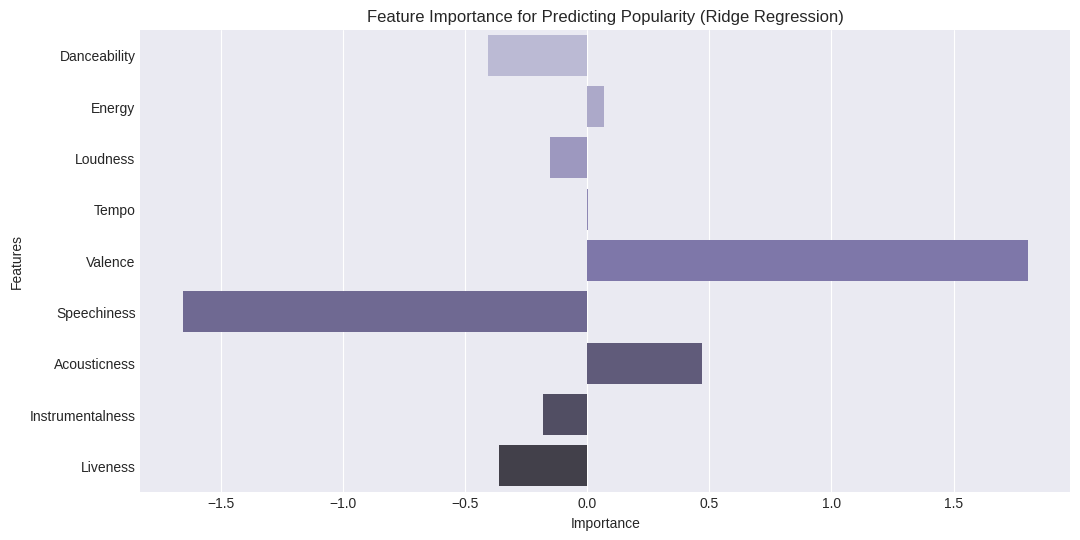

Random Forest R^2 score: -1.16
Ridge Regression R^2 score: 0.00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Feature importance with Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance from the Random Forest model
rf_importance = rf.feature_importances_

# Plot Random Forest feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=rf_importance, y=cluster_columns, palette='coolwarm')
plt.title('Feature Importance for Predicting Popularity (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

# Feature importance with Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_importance = ridge.coef_

# Plot Ridge Regression feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=ridge_importance, y=cluster_columns, palette='Purples_d')
plt.title('Feature Importance for Predicting Popularity (Ridge Regression)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

# Random Forest model performance
print(f"Random Forest R^2 score: {rf.score(X_test, y_test):.2f}")

# Ridge Regression model performance
print(f"Ridge Regression R^2 score: {ridge.score(X_test, y_test):.2f}")


<ipython-input-10-413cc15df8a1>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_popularity = music_df.resample('M')['Popularity'].mean().reset_index()


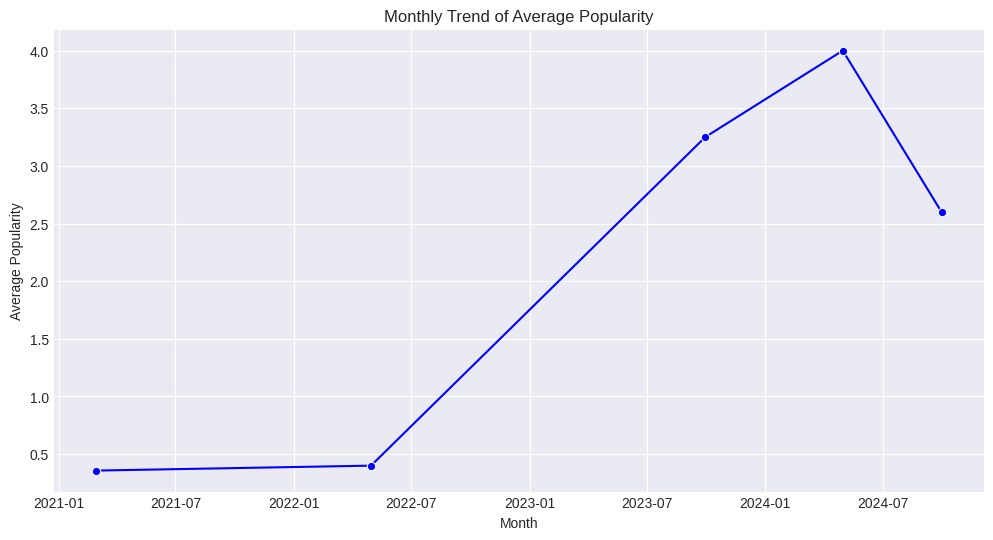

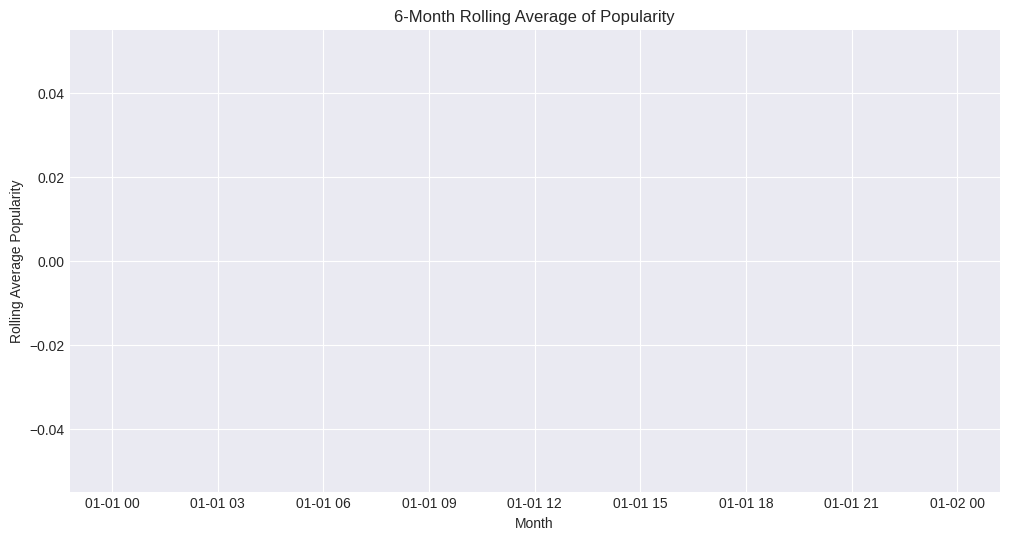

In [ ]:
# Assuming the 'Release Date' column is in datetime format

if 'Release Date' in music_df.columns:
    # Resample by month to get average popularity per month
    music_df.set_index('Release Date', inplace=True)
    monthly_popularity = music_df.resample('M')['Popularity'].mean().reset_index()

    # Plot monthly popularity trend
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Release Date', y='Popularity', data=monthly_popularity, marker='o', color='blue')
    plt.title('Monthly Trend of Average Popularity')
    plt.xlabel('Month')
    plt.ylabel('Average Popularity')
    plt.show()

    # Calculate rolling average (e.g., 6-month rolling average)
    monthly_popularity['Rolling Average'] = monthly_popularity['Popularity'].rolling(window=6).mean()

    # Plot rolling average popularity trend
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Release Date', y='Rolling Average', data=monthly_popularity, marker='o', color='green')
    plt.title('6-Month Rolling Average of Popularity')
    plt.xlabel('Month')
    plt.ylabel('Rolling Average Popularity')
    plt.show()
else:
    print("Release Date information is not available.")


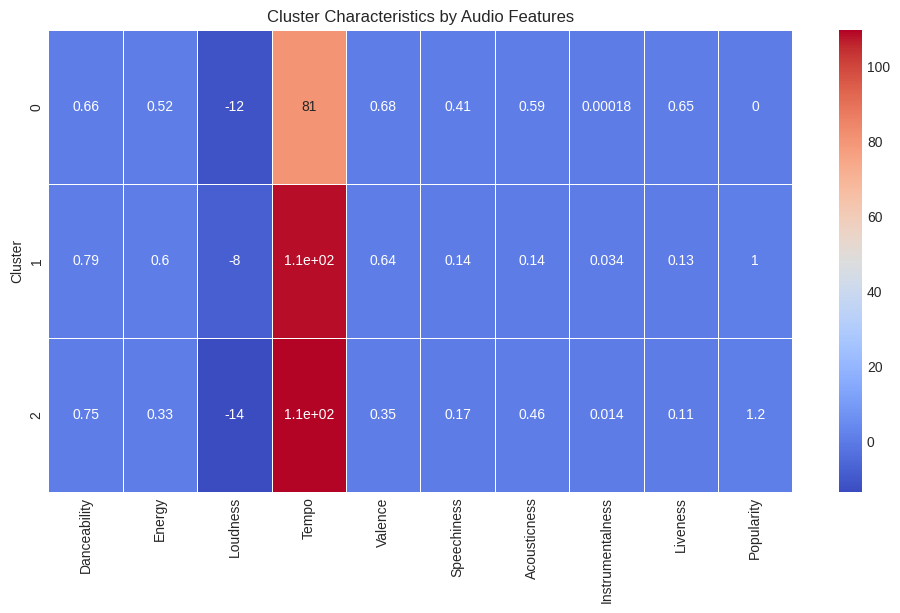

<ipython-input-11-1f897acfb780>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Popularity', data=music_df, palette='Blues_d')


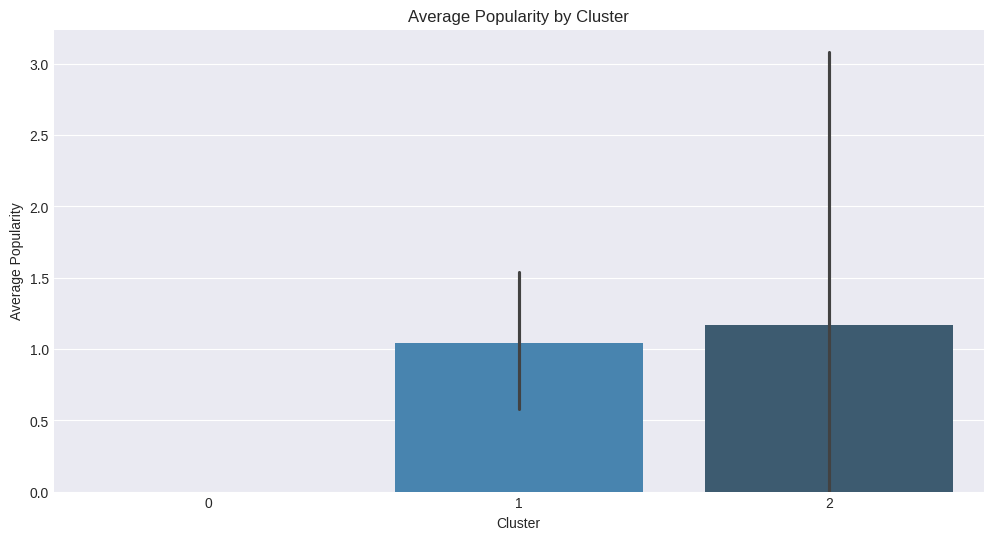

In [ ]:
# Explore the characteristics of each cluster
cluster_summary = music_df.groupby('Cluster')[cluster_columns + ['Popularity']].mean().reset_index()

# Visualize the mean feature values for each cluster
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary.set_index('Cluster'), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Cluster Characteristics by Audio Features')
plt.show()

# Plot popularity per cluster
plt.figure(figsize=(12, 6))
sns.barplot(x='Cluster', y='Popularity', data=music_df, palette='Blues_d')
plt.title('Average Popularity by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Popularity')
plt.show()


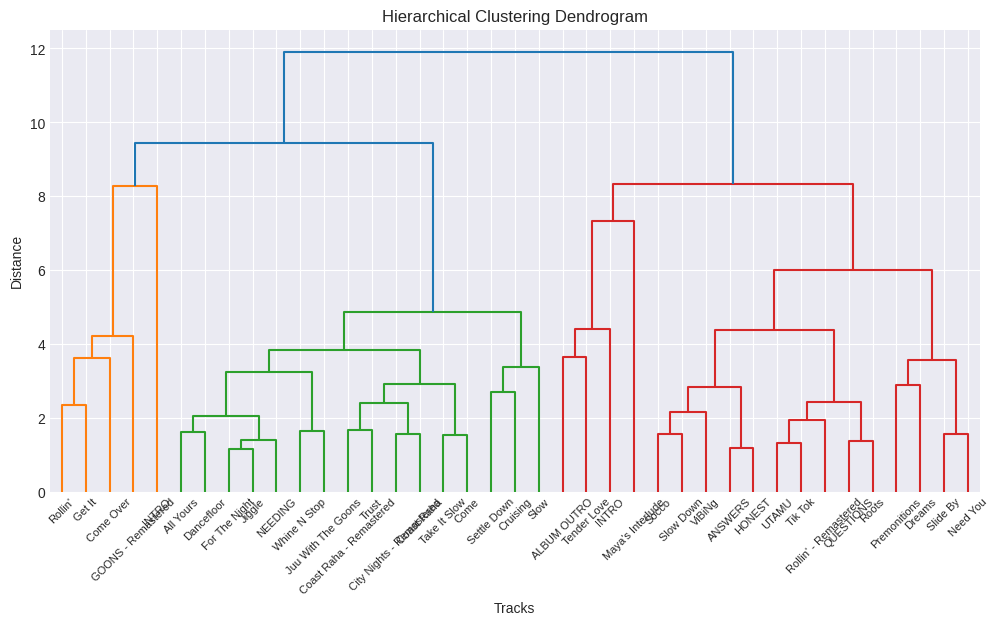

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Perform hierarchical clustering using 'ward' linkage
linked = linkage(scaled_features, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', labels=music_df['Track Name'].values, distance_sort='descending', show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Tracks')
plt.ylabel('Distance')
plt.show()

# Agglomerative clustering (similar to hierarchical but gives cluster labels)
hierarchical_cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
music_df['Hierarchical Cluster'] = hierarchical_cluster.fit_predict(scaled_features)

# Visualize clusters with hierarchical clustering
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Danceability', y='Energy', hue='Hierarchical Cluster', data=music_df, palette='viridis', s=100, alpha=0.8)
plt.title('Hierarchical Clustering of Tracks')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()


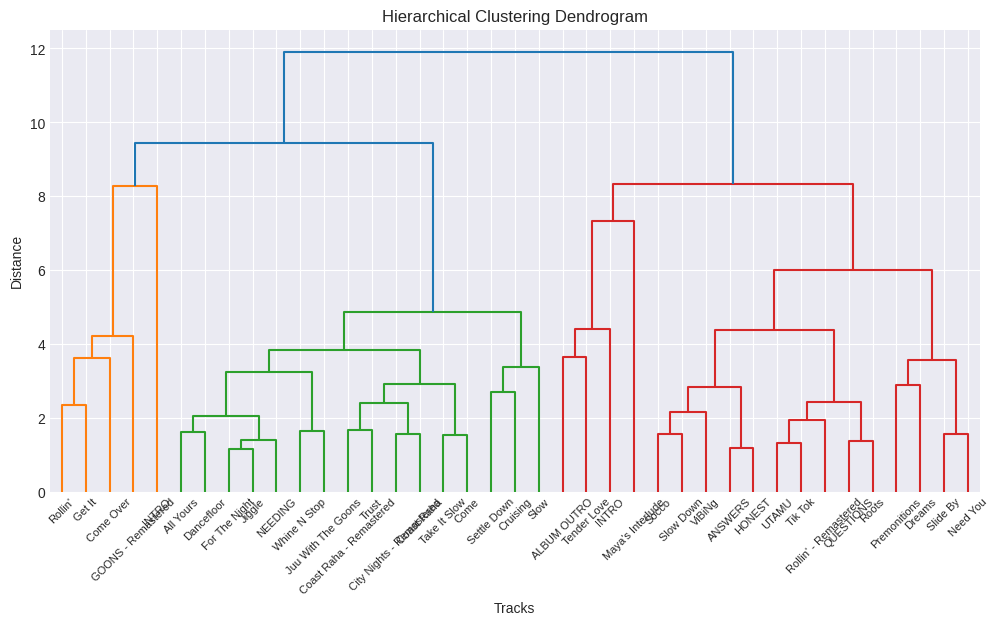

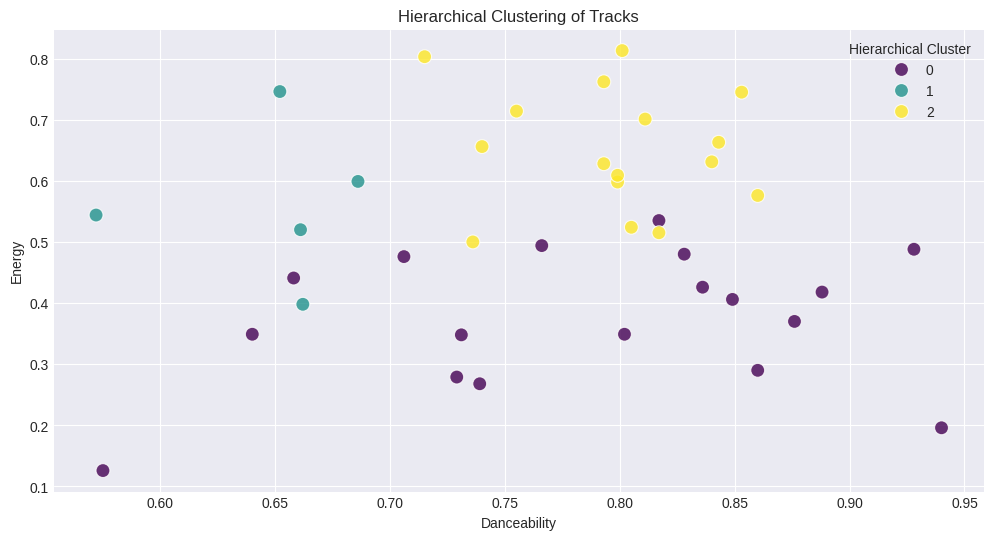

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering using 'ward' linkage
linked = linkage(scaled_features, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', labels=music_df['Track Name'].values, distance_sort='descending', show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Tracks')
plt.ylabel('Distance')
plt.show()

# Agglomerative clustering (replace 'affinity' with 'metric')
hierarchical_cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
music_df['Hierarchical Cluster'] = hierarchical_cluster.fit_predict(scaled_features)

# Visualize clusters with hierarchical clustering
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Danceability', y='Energy', hue='Hierarchical Cluster', data=music_df, palette='viridis', s=100, alpha=0.8)
plt.title('Hierarchical Clustering of Tracks')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


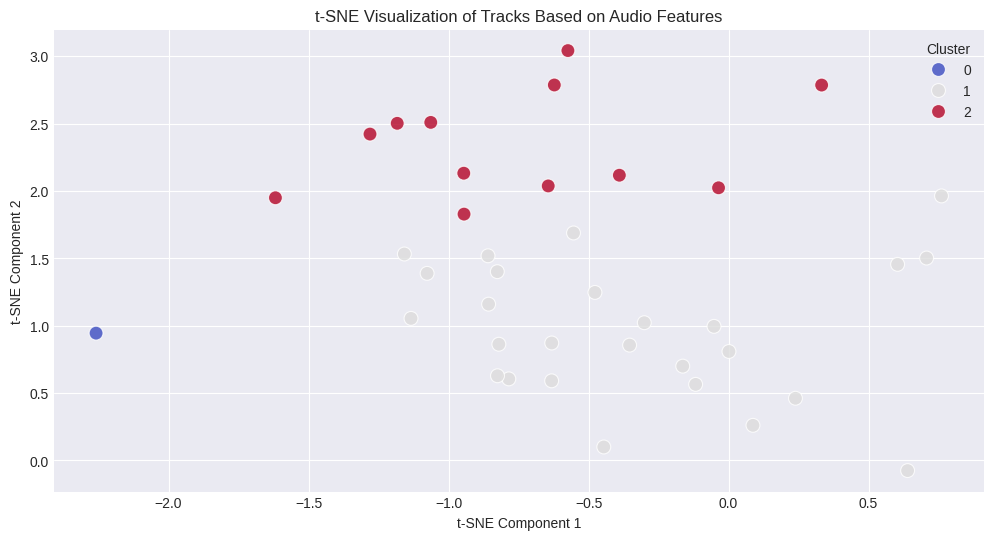

In [ ]:
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
tsne_result = tsne.fit_transform(scaled_features)

# Add t-SNE components to the DataFrame for visualization
music_df['TSNE1'] = tsne_result[:, 0]
music_df['TSNE2'] = tsne_result[:, 1]

# Plot t-SNE results
plt.figure(figsize=(12, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=music_df, palette='coolwarm', s=100, alpha=0.8)
plt.title('t-SNE Visualization of Tracks Based on Audio Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


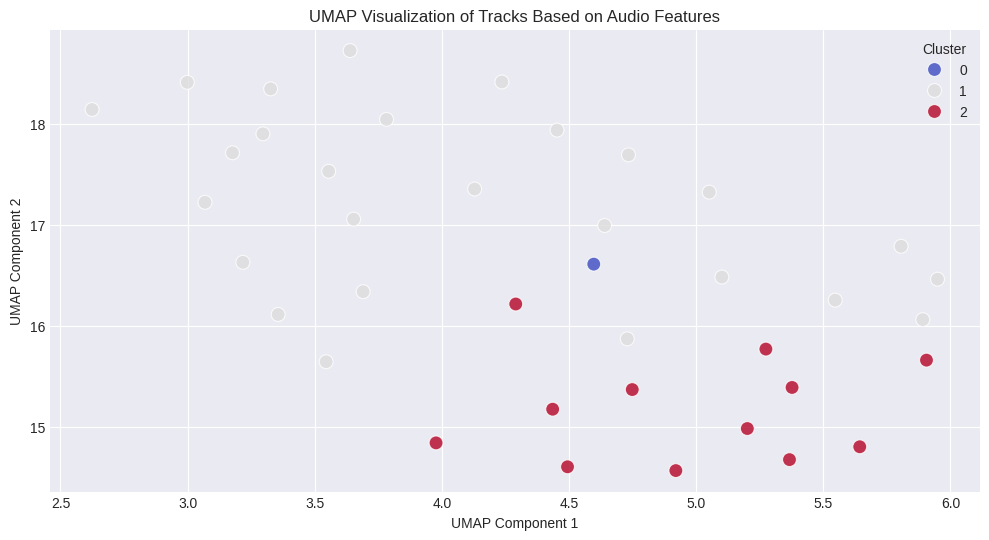

In [ ]:
!pip install umap-learn

import umap.umap_ as umap

# Perform UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(scaled_features)

# Add UMAP components to the DataFrame for visualization
music_df['UMAP1'] = umap_result[:, 0]
music_df['UMAP2'] = umap_result[:, 1]

# Plot UMAP results
plt.figure(figsize=(12, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', data=music_df, palette='coolwarm', s=100, alpha=0.8)
plt.title('UMAP Visualization of Tracks Based on Audio Features')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Assuming the 'Release Date' column is in datetime format and we have monthly popularity data
if 'Release Date' in music_df.columns:
    # Monthly popularity trend
    music_df.set_index('Release Date', inplace=True)
    monthly_popularity = music_df.resample('M')['Popularity'].mean().dropna()

    # Fit ARIMA model (order can be adjusted based on ACF/PACF analysis)
    model = ARIMA(monthly_popularity, order=(1, 1, 1))
    model_fit = model.fit()

    # Forecast future popularity (e.g., next 12 months)
    forecast = model_fit.forecast(steps=12)

    # Plot the forecasted popularity
    plt.figure(figsize=(12, 6))
    plt.plot(monthly_popularity.index, monthly_popularity, label='Historical Popularity')
    plt.plot(forecast.index, forecast, label='Forecasted Popularity', color='red')
    plt.title('ARIMA Model: Forecasting Popularity Trends')
    plt.xlabel('Date')
    plt.ylabel('Popularity')
    plt.legend()
    plt.show()
else:
    print("Release Date information is not available.")


NameError: name 'music_df' is not defined

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Assuming the 'Release Date' column is in datetime format and we have monthly popularity data
if 'Release Date' in music_df.columns:
    # Monthly popularity trend
    music_df.set_index('Release Date', inplace=True)
    monthly_popularity = music_df.resample('M')['Popularity'].mean().dropna()

    # Fit ARIMA model (order can be adjusted based on ACF/PACF analysis)
    model = ARIMA(monthly_popularity, order=(1, 1, 1))
    model_fit = model.fit()

    # Forecast future popularity (e.g., next 12 months)
    forecast = model_fit.forecast(steps=12)

    # Plot the forecasted popularity
    plt.figure(figsize=(12, 6))
    plt.plot(monthly_popularity.index, monthly_popularity, label='Historical Popularity')
    plt.plot(forecast.index, forecast, label='Forecasted Popularity', color='red')
    plt.title('ARIMA Model: Forecasting Popularity Trends')
    plt.xlabel('Date')
    plt.ylabel('Popularity')
    plt.legend()
    plt.show()
else:
    print("Release Date information is not available.")


Release Date information is not available.


In [ ]:
!pip install fbprophet
from fbprophet import Prophet
import pandas as pd

# Prepare data for Prophet
if 'Release Date' in music_df.columns:
    popularity_time_series = monthly_popularity.reset_index()
    popularity_time_series.columns = ['ds', 'y']  # Prophet requires specific column names

    # Initialize and fit Prophet model
    model = Prophet()
    model.fit(popularity_time_series)

    # Forecast future popularity
    future = model.make_future_dataframe(periods=12, freq='M')
    forecast = model.predict(future)

    # Plot forecast
    model.plot(forecast)
    plt.title('Prophet Model: Forecasting Popularity Trends')
    plt.xlabel('Date')
    plt.ylabel('Popularity')
    plt.show()

    # Plot forecast components (trend, seasonality)
    model.plot_components(forecast)
    plt.show()
else:
    print("Release Date information is not available.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 33.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for fbprophet
  Running setu

ModuleNotFoundError: No module named 'fbprophet'